In [2]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
from  matplotlib.lines import Line2D

import numpy as np
import numpy.lib.recfunctions as rfn
from   numpy.polynomial.legendre import legval

import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

from scipy.special import eval_legendre,legendre,factorial
from scipy.optimize import curve_fit, least_squares, differential_evolution

import pickle

from decimal import Decimal

from Fonctions.Vopt import V_opt
from Fonctions.Metriques import rsq, rmse, mae
from Fonctions.Affichage import plot_interactif

# Import des données

In [3]:
# Tableau : He-HCN
He = np.genfromtxt("Data/He-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

params_He = np.array([ 1.69637,    0.18540,   0.19384,  -0.01302, -0.00719,-0.02571, # b
                      -19454.791, -23297.750,-9250.9937,-45021.967,                  # c
                       11.90598,   1.33541,   2.23321,   0.31214,  0.06321,-0.13334, # d
                       0.12724,   -0.36813,  -0.18070,   0.00010,  0.24256,-0.00422, # g0
                       0.05486,    0.08842,   0.06785,  -0.01495, -0.11374, 0.02042, # g1
                      -0.01311,    0.00038,  -0.00099,   0.00252,  0.01929,-0.00554, # g2
                       0.00053,   -0.00076,  -0.00059,   0.00002, -0.00112, 0.00036])# g3

# Conversion des µEh en mEh
energy_mEh = He['Energy'] * 1e-3
# Ajout de la colonne en Eh
He = rfn.append_fields(He, names='Energy_mEh', data=energy_mEh, usemask=False)

# Méthode 1 : curve_fit

In [4]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

## He-HCN

### Calculs

In [5]:
R = np.asarray(He["R"], dtype=float)
Theta = np.asarray(He["Theta"], dtype=float)
V_table = np.asarray(He["Energy"], dtype=float)
V_table_mEh = np.asarray(He["Energy_mEh"], dtype=float)
R.shape, Theta.shape, V_table.shape

((138,), (138,), (138,))

In [6]:
#params_init_cf = 10 * np.random.rand(40) - 5
#print(params_init_cf)
params_opt_cf, params_cov = curve_fit(V_curvefit, (R, Theta), V_table_mEh,
                                      p0=params_He, maxfev=1000000,
                                      method="lm")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R, Theta), V_table_mEh,
                                      p0=params_He, maxfev=1000000,
                                      method="lm", sigma=V_table_mEh)

In [7]:
b  = params_opt_cf[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf[6:10]  # c0, c1, c2, c3
d  = params_opt_cf[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [2.251066764404436, -0.782616264794794, 0.48682590398070724, -0.059954536747380716, -0.00029742261867830063, 0.04636533121946466]
[c0,c1,c2,c3]             = [-19666.666799588256, -18608.59331178838, -10980.937103896562, -24350.398234603897]
[d0,d1,d2,d3,d4,d5]       = [16.8204455654615, -4.680021786717925, 4.54686137717552, 0.10548489347993371, 0.26065518918572367, 0.3014333315297033]
[g00,g01,g02,g03,g04,g05] = [-0.04712418247042, 0.06811639701597398, -0.2043353772217847, 0.13453444482066831, -0.018794437298640703, 0.03568213503606949]
[g10,g11,g12,g13,g14,g15] = [0.033532773920381724, -0.03578123043527122, 0.12263041299329573, -0.08726007334105558, 0.00836876081422265, -0.017344716723002192]
[g20,g21,g22,g23,g24,g25] = [-0.005606721921295177, 0.009587705406922852, -0.025129669057288754, 0.017363337173203448, -0.0014031810522002783, 0.0025993645023465535]
[g30,g31,g32,g33,g34,g35] = [0.0003201977946553137, -0.0008948099059711583, 0.0017282591288976029, -0.

In [8]:
print(params_opt_cf)
print(params_opt_cf_sigma)

[ 2.25106676e+00 -7.82616265e-01  4.86825904e-01 -5.99545367e-02
 -2.97422619e-04  4.63653312e-02 -1.96666668e+04 -1.86085933e+04
 -1.09809371e+04 -2.43503982e+04  1.68204456e+01 -4.68002179e+00
  4.54686138e+00  1.05484893e-01  2.60655189e-01  3.01433332e-01
 -4.71241825e-02  6.81163970e-02 -2.04335377e-01  1.34534445e-01
 -1.87944373e-02  3.56821350e-02  3.35327739e-02 -3.57812304e-02
  1.22630413e-01 -8.72600733e-02  8.36876081e-03 -1.73447167e-02
 -5.60672192e-03  9.58770541e-03 -2.51296691e-02  1.73633372e-02
 -1.40318105e-03  2.59936450e-03  3.20197795e-04 -8.94809906e-04
  1.72825913e-03 -1.10203089e-03  7.54069994e-05 -1.18210947e-04]
[ 1.50934275e+00 -1.44605913e-01  3.58941694e-01 -2.47745925e-01
  4.24733156e-03  5.27763789e-03 -1.72697380e+04 -2.19589988e+04
 -8.63337725e+03 -6.57602587e+03  1.19653233e+01 -2.34663640e+00
  4.18766987e+00 -1.28745199e+00  5.56687174e-01 -3.91421778e-05
  4.94669268e-01  5.65991474e-01 -2.35701827e-02  1.43378598e-01
  2.75519921e-01  9.1211

In [9]:
print(np.array2string(
    params_opt_cf_sigma,
    formatter={'float_kind': lambda x: f"{x:.12f}"}
))

[1.509342746542 -0.144605912968 0.358941694183 -0.247745924632
 0.004247331560 0.005277637888 -17269.737954589044 -21958.998791054608
 -8633.377245311987 -6576.025870423045 11.965323282601 -2.346636401351
 4.187669869195 -1.287451985151 0.556687174127 -0.000039142178
 0.494669267681 0.565991474147 -0.023570182744 0.143378598277
 0.275519921361 0.009121141363 -0.132725254798 -0.134235628551
 0.038880970910 -0.064480449795 -0.130717490837 -0.011049491674
 0.012137693966 0.010026266603 -0.007334442173 0.008730039046
 0.018490520522 0.001829474458 -0.000441323442 -0.000293942417
 0.000370008581 -0.000342605568 -0.000798494187 -0.000071426394]


In [10]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R, Theta)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R, Theta)
V_params_these = V_opt(params_He, R, Theta)

r2_cf = rsq(V_table_mEh, V_pred_cf)
r2_cf_sigma = rsq(V_table_mEh, V_pred_cf_sigma)
r2_params_these = rsq(V_table_mEh, V_params_these)

rmse_cf = rmse(V_table_mEh, V_pred_cf)
rmse_cf_sigma = rmse(V_table_mEh, V_pred_cf_sigma)
rmse_params_these = rmse(V_table_mEh, V_params_these)

mae_cf = mae(V_table_mEh, V_pred_cf)
mae_cf_sigma = mae(V_table_mEh, V_pred_cf_sigma)
mae_params_these = mae(V_table_mEh, V_params_these)

print(f"R² (sans sigma)         : {r2_cf}")
print(f"R² (avec sigma=y)       : {r2_cf_sigma}")
print(f"R² (paramètres these)   : {r2_params_these}")
print()
print(f"rmse (sans sigma)       : {rmse_cf}")
print(f"rmse (avec sigma=y)     : {rmse_cf_sigma}")
print(f"rmse (paramètres these) : {rmse_params_these}")
print()
print(f"mae (sans sigma)        : {mae_cf}")
print(f"mae (avec sigma=y)      : {mae_cf_sigma}")
print(f"mae (paramètres these)  : {mae_params_these}")

R² (sans sigma)         : 0.9999998008339221
R² (avec sigma=y)       : 0.9950383123009631
R² (paramètres these)   : 0.7536818940425544

rmse (sans sigma)       : 0.0009195141090237767
rmse (avec sigma=y)     : 0.14513275005385773
rmse (paramètres these) : 1.0225837339273804

mae (sans sigma)        : 0.0007068607887561654
mae (avec sigma=y)      : 0.022567749319411003
mae (paramètres these)  : 0.09172435620735993


In [11]:
# 1. Données d'entrée
#R_list = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 10.0, 12.0]
R_list = [6.7,6.8,6.9,7.0,7.6,7.7,7.8,7.9,8.1]
#Theta_list = [0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180]
Theta_list = [0,105, 110, 115, 120, 180]

# 2. Calcul des énergies (en mEh)
res = np.array([
    V_opt(params_opt_cf_sigma, np.full_like(Theta_list, r, dtype=float), Theta_list)
    for r in R_list
])

# 3. Conversion de toute la matrice en µEh d'un seul coup
res_uEh = res * 1000

# 4. Configuration de l'affichage
largeur_r = 10  # Largeur pour la colonne de gauche 'R \ Theta'
largeur_th = 12  # Largeur pour chaque colonne de données
nb_colonnes = len(Theta_list)

# Ligne de séparation (|-------...-------|)
ligne_separation = "|" + "-" * (largeur_r + nb_colonnes * (largeur_th + 1)) + "|"

# --- Début de l'affichage ---

print(ligne_separation)
# Entête
entete_cols = "".join(f" {th:>{largeur_th}}" for th in Theta_list)
print(f"|{'R \\ Theta':<{largeur_r}}{entete_cols} |")
print(ligne_separation)

# Remplissage des lignes de données
for i, r in enumerate(R_list):
    # Colonne R
    ligne_str = f"|  {r:<{largeur_r-2}.1f}|"

    # Parcours des valeurs précalculées pour cette ligne (ce R)
    for val_uEh in res_uEh[i]:
        # Affichage de la valeur à 4 décimales, calée à droite
        ligne_str += f" {val_uEh:>{largeur_th}.4f}"

    ligne_str += " |"
    print(ligne_str)

print(ligne_separation)

|----------------------------------------------------------------------------------------|
|R \ Theta             0          105          110          115          120          180 |
|----------------------------------------------------------------------------------------|
|  6.7     |     858.4965    -100.0915     -99.2609     -97.3587     -93.9898     104.4594 |
|  6.8     |     609.5898    -100.1490    -100.1095     -99.4004     -97.7153      49.4293 |
|  6.9     |     415.7639     -98.7944     -99.3553     -99.5600     -99.1675       7.3313 |
|  7.0     |     265.9471     -96.4004     -97.4089     -98.3021     -98.8869     -24.3761 |
|  7.6     |    -106.0212     -73.0098     -74.8661     -77.1519     -79.7704     -89.7985 |
|  7.7     |    -121.4461     -68.8466     -70.6828     -72.9569     -75.5749     -89.8252 |
|  7.8     |    -130.6423     -64.7960     -66.5915     -68.8219     -71.3956     -88.4824 |
|  7.9     |    -135.1224     -60.8897     -62.6293     -64.7925     -67.28

# Affichage des résultats

## Plot à variable fixée

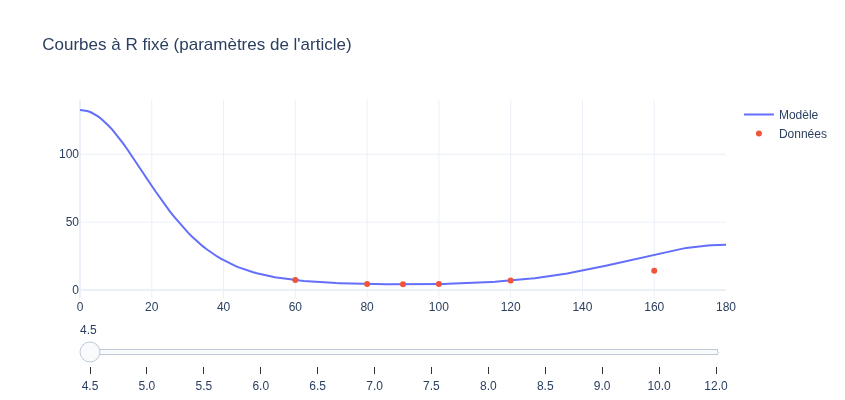

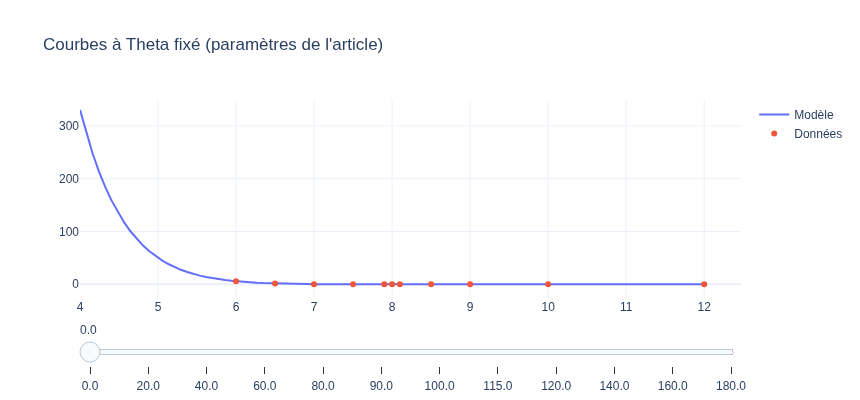

In [12]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_He, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé (paramètres de l'article)")
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_He, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé (paramètres de l'article)",fixed_first=False)

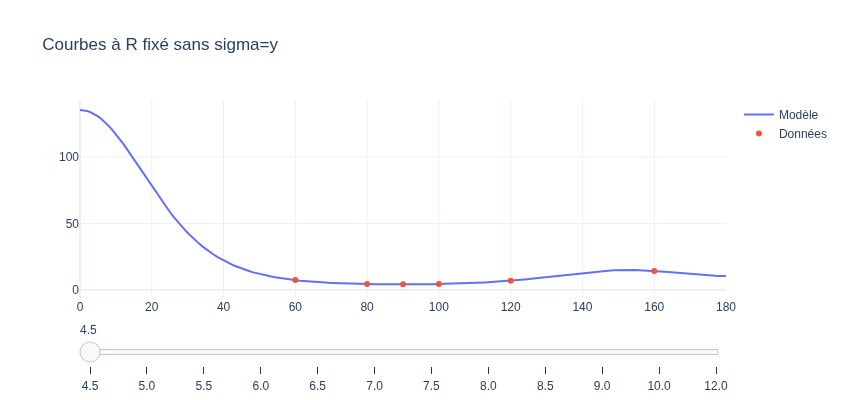

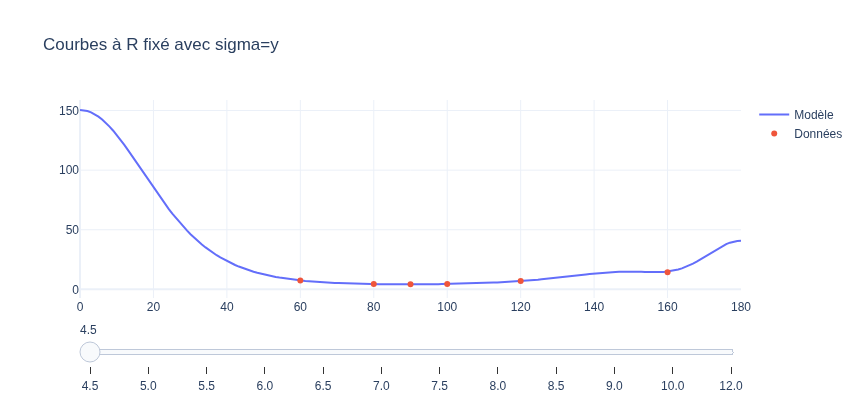

In [13]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec sigma=y")

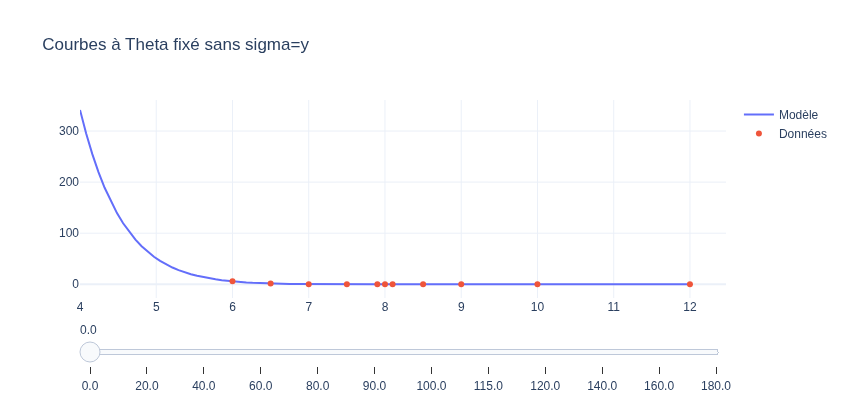

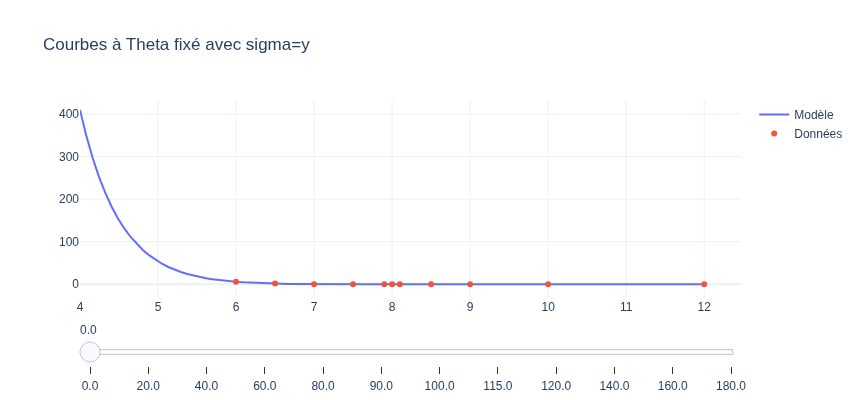

In [14]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_opt_cf, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé sans sigma=y",fixed_first=False)
plot_interactif(V_opt, params_opt_cf_sigma, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

## Contour plot

In [15]:
def contour_plot(ax, params, title):
    # Axes
    theta_grid = np.linspace(0, 180, 250)
    r_grid = np.linspace(6, 10, 250)
    
    Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)
    
    # Calcul de Z
    Z = np.array([
        V_opt(params, np.full_like(theta_grid, r), theta_grid)
        for r in r_grid
    ])
    
    # Niveaux
    levels_to_plot = np.array([
        -0.026, -0.039,-0.051, -0.063, -0.075, -0.087,
        -0.094, -0.100, -0.112, -0.124, -0.133
    ])
    
    levels_with_labels = levels_to_plot
    
    # niveaux intermédiaires
    levels_fine = []
    for i in range(len(levels_to_plot) - 1):
        a, b = levels_to_plot[i], levels_to_plot[i + 1]
        inter = np.linspace(a, b, 6)
        levels_fine.extend(inter[1:-1])
    
    levels_fine = np.sort(np.unique(levels_fine))
    
    # Contours gris
    ax.contour(
        Theta_mesh, R_mesh, Z,
        levels=levels_fine,
        colors='gray',
        linewidths=0.7
    )
    
    # Contours principaux
    all_contours = []
    for level in levels_to_plot:
        cp = ax.contour(
            Theta_mesh, R_mesh, Z,
            levels=[level],
            colors='black',
            linewidths=1.5,
            linestyles='--'
        )
        all_contours.append(cp)
    
    # Labels
    for cp in all_contours:
        level = cp.levels[0]
        if np.isclose(levels_with_labels, level).any():
            ax.clabel(cp, fmt='%.3f', fontsize=10, inline=True)

    theta_values = np.arange(0,181,20)
    r_dense = np.linspace(6,10,300) # Grille dense pour trouver le minimum avec précision

    # Affichage des Max et Min selon le R
    for th_val in theta_values:
        energies = V_opt(params, r_dense, np.full_like(r_dense,th_val))

        # Minimum
        min_idx = np.argmin(energies)
        min_E = energies[min_idx]
        min_r = r_dense[min_idx]
        # Maximum
        #max_idx = np.argmax(energies)
        #max_E = energies[max_idx]
        #max_r = r_dense[max_idx]
        
        # Affichage du point
        ax.plot(th_val, min_r, marker='v', color='red', markersize=5)
        #ax.plot(max_r, th_val, marker='^', color='blue', markersize=5)
        
        # Affichage de la valeur
        offset = -15 if th_val > 150 else 3
        ax.text(th_val + offset, min_r, f"{min_E:.3f}", color='red', 
                fontsize=9, verticalalignment='center')
        #ax.text(max_r + 3, th_val, f"{max_E:.3f}", color='blue', 
        #        fontsize=9, verticalalignment='center')
    
    ax.set_title(f"He-HCN - Energie potentielle (mEh)\n{title}")
    ax.set_xlabel("Theta (°)")
    ax.set_ylabel("R")
    
    ax.set_yticks(np.arange(6, 10.5, 0.5))
    ax.set_xticks(np.arange(0, 181, 20))
    
    ax.grid(True, linestyle='--', alpha=0.3)

    legende_point1 = Line2D([0], [0], linestyle='None', marker='v', color='red', 
                           markersize=5, label="Energie min")
    #legende_point2 = Line2D([0], [0], linestyle='None', marker='^', color='blue', 
    #                       markersize=5, label="Energie max")
    #legende_point = [legende_point2, legende_point1]
    ax.legend(handles=[legende_point1],loc='upper right', fontsize=10, framealpha=0.9)

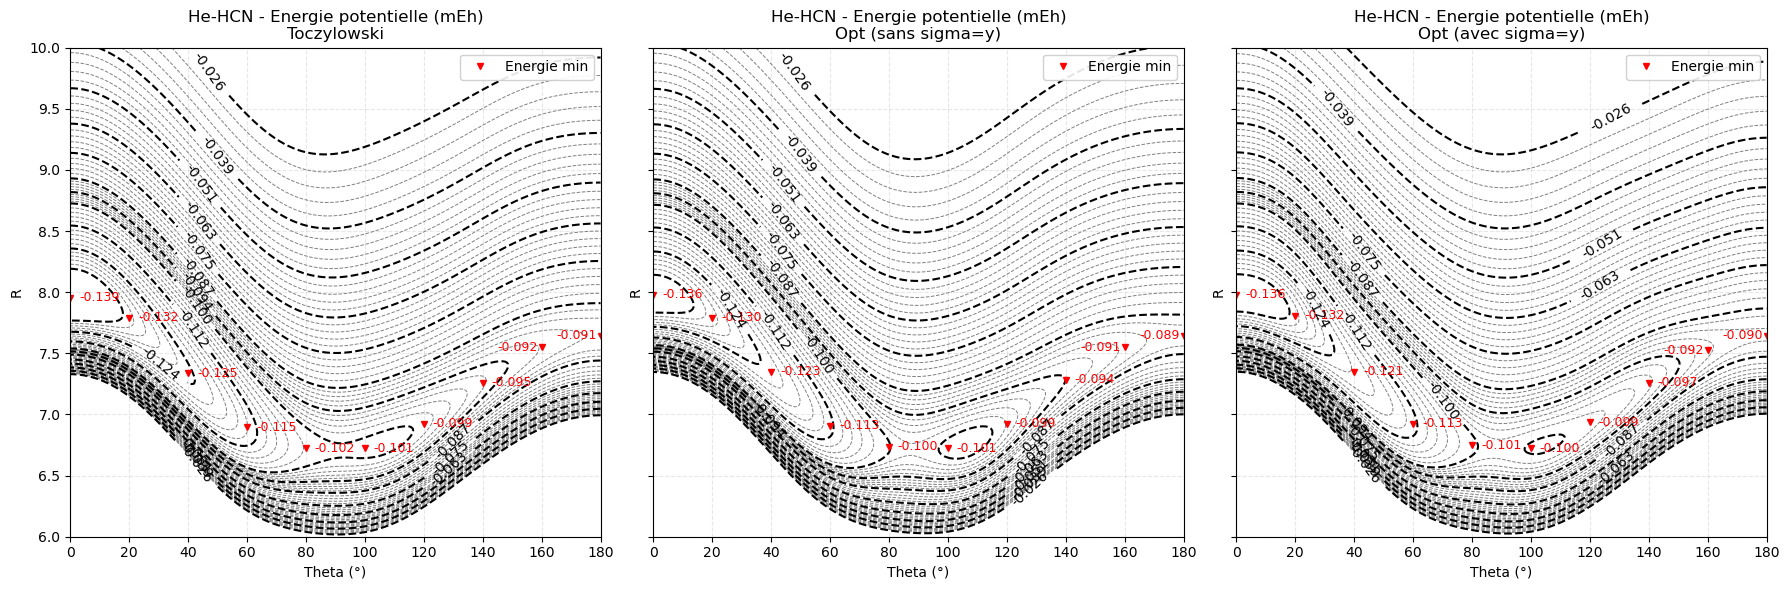

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

contour_plot(axes[0], params_He, "Toczylowski")
contour_plot(axes[1], params_opt_cf, "Opt (sans sigma=y)")
contour_plot(axes[2], params_opt_cf_sigma, "Opt (avec sigma=y)")

plt.tight_layout()

## Affichage des minimums

In [21]:
def minimums(ax, params, title):
    theta_grid = np.linspace(0, 180, 500)
    r_dense = np.linspace(6, 10, 500)

    R_min_list = []
    E_min_list = []

    for theta_val in theta_grid:
        energies = V_opt(params, r_dense, np.full_like(r_dense, theta_val))
        
        # Extraction du minimum pour ce theta
        min_idx = np.argmin(energies)
        R_min_list.append(r_dense[min_idx])
        E_min_list.append(energies[min_idx])
        
    # Energie minimale
    line1 = ax.plot(theta_grid, E_min_list, color='crimson', linewidth=1.5, 
                    marker='.', markersize=3, label="Énergie min")

    ax.set_title(f"Ne-HCN - Énergie et Distance minimales en fonction de Theta\n{title}")
    ax.set_xlabel("Theta en °")
    ax.set_ylabel("Énergie minimale (mEh)", color='crimson')
    ax.tick_params(axis='y', labelcolor='crimson') # Colorer les ticks pour plus de clarté
    
    ax.grid(True, linestyle='--', alpha=0.5)

    # R correspondant
    ax2 = ax.twinx() # 2e axe y, même axe x
    line2 = ax2.plot(theta_grid, R_min_list, color='teal', linewidth=1.5, 
                     marker='.', markersize=3, label="R min")
                     
    ax2.set_ylabel("Distance R correspondante", color='teal')
    ax2.tick_params(axis='y', labelcolor='teal')

    # Légende
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='best')


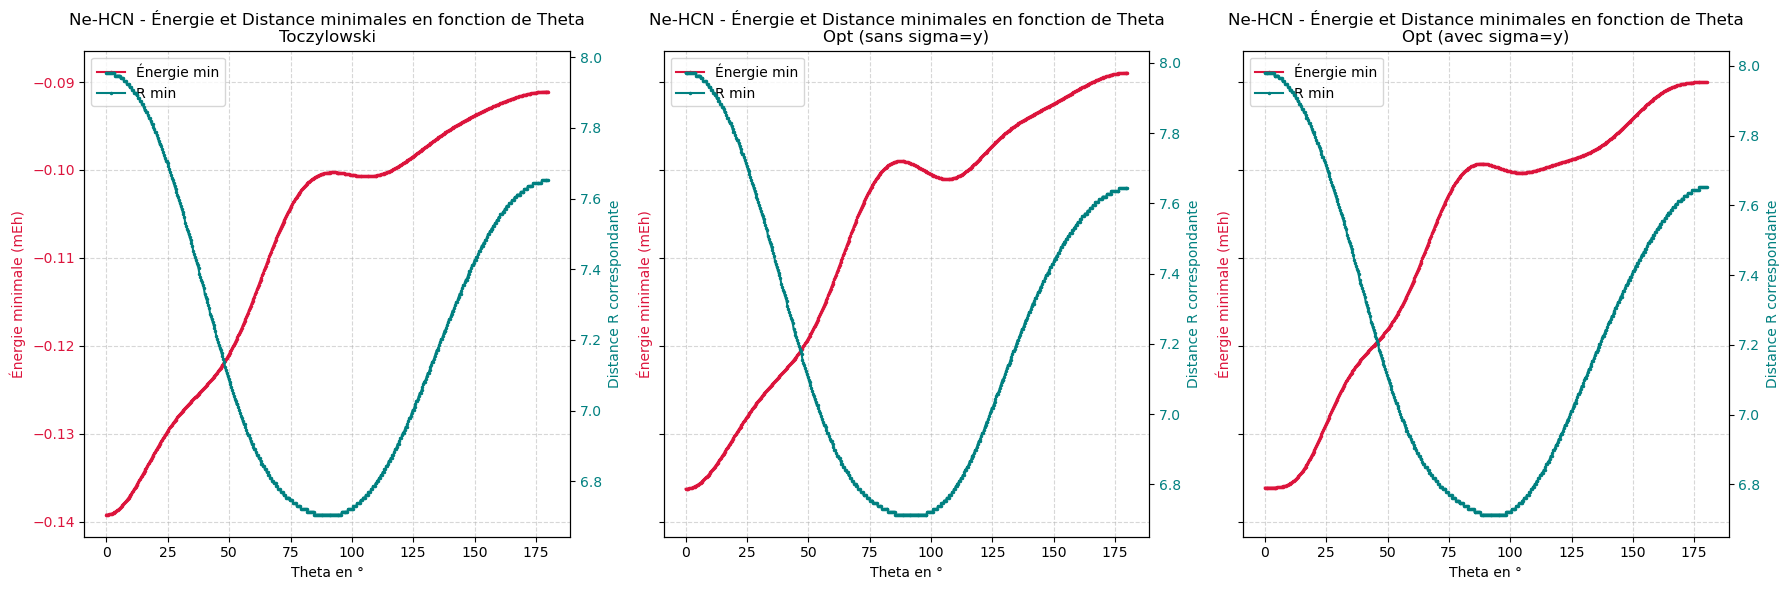

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

minimums(axes[0], params_He, "Toczylowski")
minimums(axes[1], params_opt_cf, "Opt (sans sigma=y)")
minimums(axes[2], params_opt_cf_sigma, "Opt (avec sigma=y)")

plt.tight_layout()

# Methode 2 : least_squares


In [17]:
def residus_He(params):
    V_pred = V_opt(params, He["R"], He["Theta"])
    # .ravel() force le résultat en un tableau 1D pour least_squares
    return (V_pred - He["Energy_mEh"]).ravel()

In [18]:
result1 = least_squares(residus_He, params_He)
params_opt_ls = result1.x

result2 = least_squares(residus_He, params_He, x_scale = "jac")
params_opt_ls_jac = result2.x

In [19]:
result3 = least_squares(residus_He, params_He, 
                        x_scale = "jac", loss="soft_l1")
params_opt_ls_jac_soft = result3.x

In [20]:
result4 = least_squares(residus_He, params_He, 
                        x_scale = "jac", loss="huber")
params_opt_ls_jac_huber = result4.x

In [21]:
V_pred_ls = V_opt(params_opt_ls, R, Theta)
V_pred_ls_jac = V_opt(params_opt_ls_jac, R, Theta)
V_pred_ls_jac_soft = V_opt(params_opt_ls_jac_soft, R, Theta)
V_pred_ls_jac_huber = V_opt(params_opt_ls_jac_huber, R, Theta)

r2_ls = rsq(V_table_mEh, V_pred_ls)
r2_ls_jac = rsq(V_table_mEh, V_pred_ls_jac)
r2_ls_jac_soft = rsq(V_table_mEh, V_pred_ls_jac_soft)
r2_ls_jac_huber = rsq(V_table_mEh, V_pred_ls_jac_huber)

rmse_ls = rmse(V_table_mEh, V_pred_ls)
rmse_ls_jac = rmse(V_table_mEh, V_pred_ls_jac)
rmse_ls_jac_soft = rmse(V_table_mEh, V_pred_ls_jac_soft)
rmse_ls_jac_huber = rmse(V_table_mEh, V_pred_ls_jac_huber)

mae_ls = mae(V_table_mEh, V_pred_ls)
mae_ls_jac = mae(V_table_mEh, V_pred_ls_jac)
mae_ls_jac_soft = mae(V_table_mEh, V_pred_ls_jac_soft)
mae_ls_jac_huber = mae(V_table_mEh, V_pred_ls_jac_huber)

print(f"R²                                   : {r2_ls}")
print(f"R²   (x_scale='jac')                 : {r2_ls_jac}")
print(f"R²   (x_scale='jac', 'loss=soft_l1') : {r2_ls_jac_soft}")
print(f"R²   (x_scale='jac', 'loss=huber')   : {r2_ls_jac_huber}")
print()
print(f"rmse                                 : {rmse_ls}")
print(f"rmse (x_scale='jac')                 : {rmse_ls_jac}")
print(f"rmse (x_scale='jac', loss='soft_l1') : {rmse_ls_jac_soft}")
print(f"rmse (x_scale='jac', loss='huber')   : {rmse_ls_jac_huber}")
print()
print(f"mae                                  : {mae_ls}")
print(f"mae  (x_scale='jac')                 : {mae_ls_jac}")
print(f"mae  (x_scale='jac', loss='soft_l1') : {mae_ls_jac_soft}")
print(f"mae  (x_scale='jac', loss='huber')   : {mae_ls_jac_huber}")

R²                                   : 0.9999979337986399
R²   (x_scale='jac')                 : 0.9999998710239754
R²   (x_scale='jac', 'loss=soft_l1') : 0.9999999004185103
R²   (x_scale='jac', 'loss=huber')   : 0.9999999004185094

rmse                                 : 0.002961672504821794
rmse (x_scale='jac')                 : 0.0007399548230815067
rmse (x_scale='jac', loss='soft_l1') : 0.0006501896044096505
rmse (x_scale='jac', loss='huber')   : 0.0006501896072691503

mae                                  : 0.0017277451373269373
mae  (x_scale='jac')                 : 0.0005812989582115011
mae  (x_scale='jac', loss='soft_l1') : 0.0004947063555608599
mae  (x_scale='jac', loss='huber')   : 0.0004947070047232251


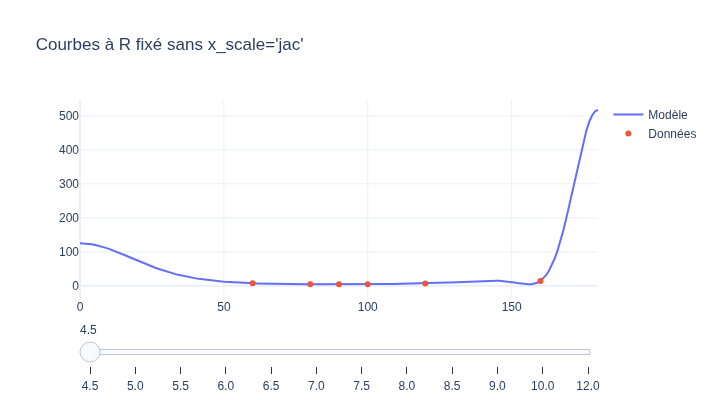

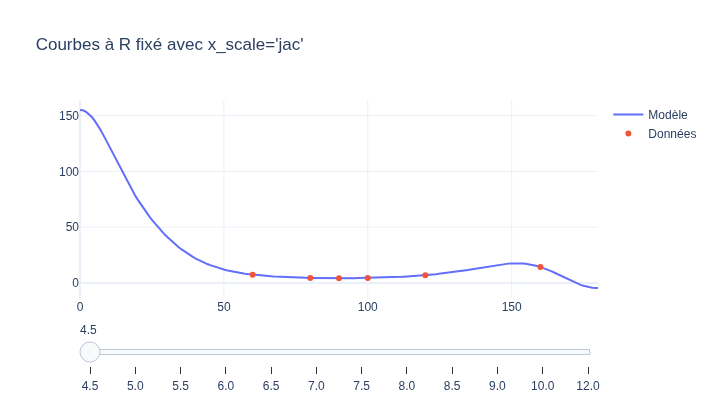

In [22]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_ls, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_opt_ls_jac, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")

## Variation des params initiaux

In [23]:
def metriques(y, y_pred, params):

  residus = y - y_pred

  rss = np.sum(residus**2)
  tss = np.sum((y - np.mean(y))**2)
  r2 = 1 - rss/tss

  mae = np.mean(np.abs(residus))
  rmse = np.sqrt(np.mean(residus**2))
  param_norm = np.linalg.norm(params)

  return {
      "rmse": rmse,
      "mae": mae,
      "r2": r2,
      "rss": rss,
      "param_norm": param_norm
      }

In [24]:
# import d'un calcul précédent de 'resultats'
with open("resultats_multistart.pkl", "rb") as f:
    resultats = pickle.load(f)

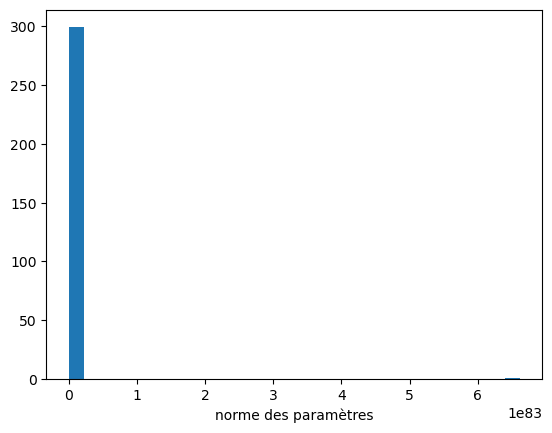

In [25]:
normes = [np.linalg.norm(r["params"]) for r in resultats]

plt.hist(normes, bins=30)
plt.xlabel("norme des paramètres")
plt.show()

In [26]:
# Tri avec rmse
best_rmse_fit = min(resultats, key=lambda r: r["rmse"])
# Solutions stables
bon = [r for r in resultats if r["rmse"] <= 1.10 * best_rmse_fit["rmse"]]

bon_r2 = [r for r in resultats if r["r2"] > 0.999999]

# On récupère tous les "bons" paramètres
params_all = np.array([r["params"] for r in bon])
# On regarde la distribution des paramètres pour
# voir s'ils sont proches
params_std = np.std(params_all, axis=0)

In [27]:
best_r2 = min(bon_r2, key=lambda r: r["mae"])
best_r2

{'params': array([ 2.16976644e+00, -8.56540259e-01,  5.44247701e-01, -6.35182204e-02,
        -1.47009717e-01, -4.78693993e-02, -1.99345245e+04, -2.31230265e+04,
        -1.05827934e+04, -1.78498477e+04,  1.05704333e+01, -4.50466617e+00,
         4.69038121e+00, -5.68216336e-02, -5.84212476e-01, -2.01865288e-01,
        -2.27842230e+01,  4.94802125e+01, -8.90024690e+01,  9.26372560e+01,
        -4.45131927e+01,  4.48792740e+01,  1.68383897e+01, -2.71082809e+01,
         5.37279037e+01, -5.68472088e+01,  2.89953166e+01, -2.10270671e+01,
        -3.34907448e+00,  5.95915835e+00, -1.12450358e+01,  1.14683309e+01,
        -5.91277676e+00,  3.21110444e+00,  2.27866386e-01, -4.81250611e-01,
         8.00881675e-01, -7.60955135e-01,  3.81311927e-01, -1.59748287e-01]),
 'rmse': np.float64(0.0006095942645154914),
 'mae': np.float64(0.0004404609293272692),
 'r2': np.float64(0.9999999124652853),
 'rss': np.float64(5.128151309156524e-05),
 'param_norm': np.float64(36914.8289402298)}

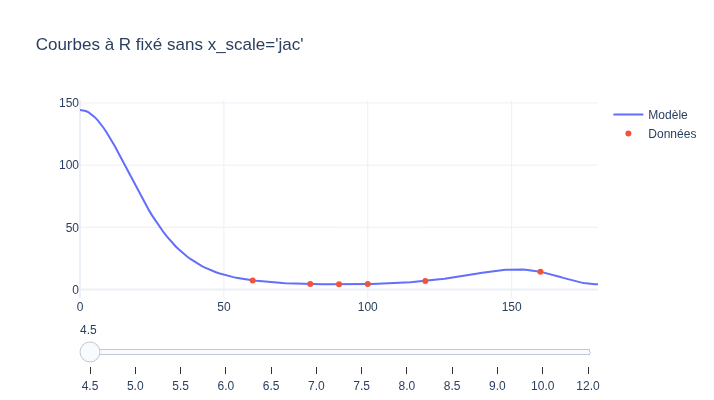

In [28]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, best_r2["params"], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")

In [29]:
precis = least_squares(residus_He, params_all[1], method="trf",
                       loss="huber", x_scale="jac", max_nfev=200000,
                       xtol=1e-12, ftol=1e-12, gtol=1e-12)

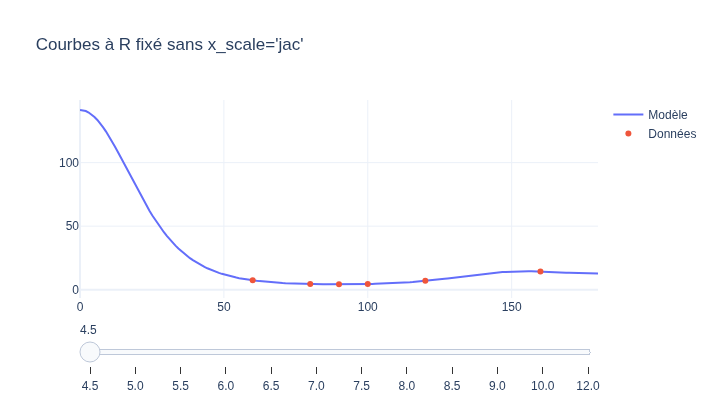

In [30]:
plot_interactif(V_opt, precis.x, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")

# Methode 3 : Differential_evolution + least_squares

In [31]:
def cout(params):
    V_pred = V_opt(params,He["R"],He["Theta"])
    resid = V_pred - He["Energy_mEh"]
    return np.mean(resid**2)

In [32]:
# On récupère les bounds à l'aide des meilleurs params
p_min = np.min(params_all, axis=0)
p_max = np.max(params_all, axis=0)
# On ajoute une marge
a = p_min - 0.2 * np.maximum(np.abs(p_min), 1e-2)
b = p_max + 0.2 * np.maximum(np.abs(p_max), 1e-2)
# Bounds
bounds = list(zip(a, b))

In [34]:
result_de = differential_evolution(
    cout,
    bounds,
    strategy="best1bin",
    maxiter=300,
    popsize=20,
    workers=4,
    polish=False,
    disp=True
)

differential_evolution step 1: f(x)= 19.659956762393264
differential_evolution step 2: f(x)= 19.659956762393264
differential_evolution step 3: f(x)= 9.280737076856088
differential_evolution step 4: f(x)= 8.138085689733838
differential_evolution step 5: f(x)= 8.138085689733838
differential_evolution step 6: f(x)= 8.138085689733838
differential_evolution step 7: f(x)= 4.980081424407972
differential_evolution step 8: f(x)= 4.980081424407972
differential_evolution step 9: f(x)= 4.168087069802346
differential_evolution step 10: f(x)= 4.168087069802346
differential_evolution step 11: f(x)= 2.944220373563132
differential_evolution step 12: f(x)= 2.944220373563132
differential_evolution step 13: f(x)= 0.9754485223987108
differential_evolution step 14: f(x)= 0.9754485223987108
differential_evolution step 15: f(x)= 0.9754485223987108
differential_evolution step 16: f(x)= 0.9754485223987108
differential_evolution step 17: f(x)= 0.9754485223987108
differential_evolution step 18: f(x)= 0.9754485223

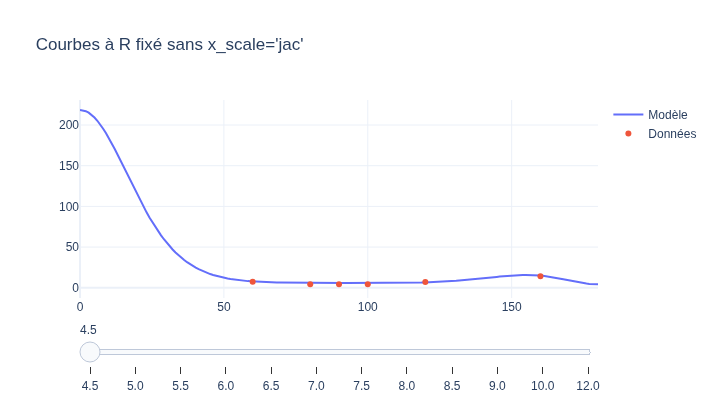

In [35]:
plot_interactif(V_opt, result_de.x, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")

In [36]:
result_ls_affinage = least_squares(
    residus_He,
    result_de.x,
    method="lm",
    loss="linear",
    x_scale=None,
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    max_nfev=100000
)

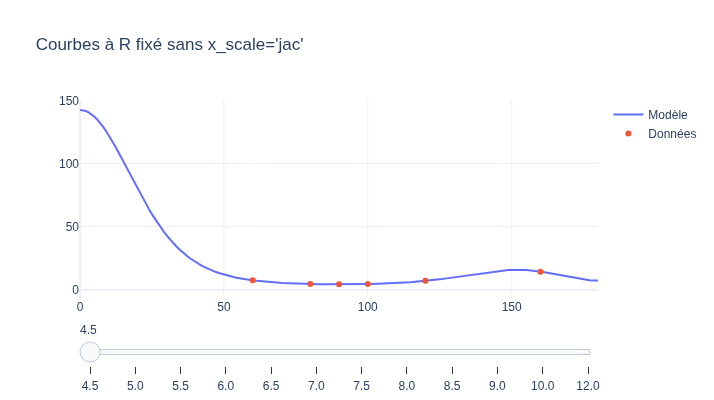

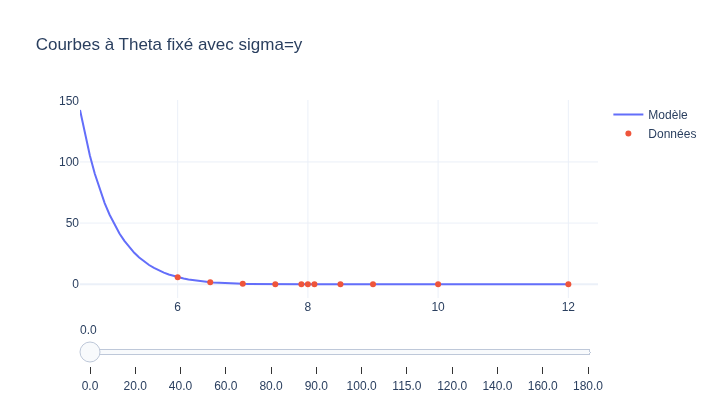

In [37]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4.5, 12, 100)
plot_interactif(V_opt, result_ls_affinage.x, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, result_ls_affinage.x, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

# R progressif

In [38]:
He1 = He[He["R"] >= 9]
He2 = He[He["R"] >= 7]
He3 = He[He["R"] >= 4]
p0 = params_He

In [39]:
def residus1(params):
    V_pred = V_opt(params, He1["R"], He1["Theta"])
    return V_pred - He1["Energy_mEh"]
def residus2(params):
    V_pred = V_opt(params, He2["R"], He2["Theta"])
    return V_pred - He2["Energy_mEh"]
def residus3(params):
    V_pred = V_opt(params, He3["R"], He3["Theta"])
    return V_pred - He3["Energy_mEh"]

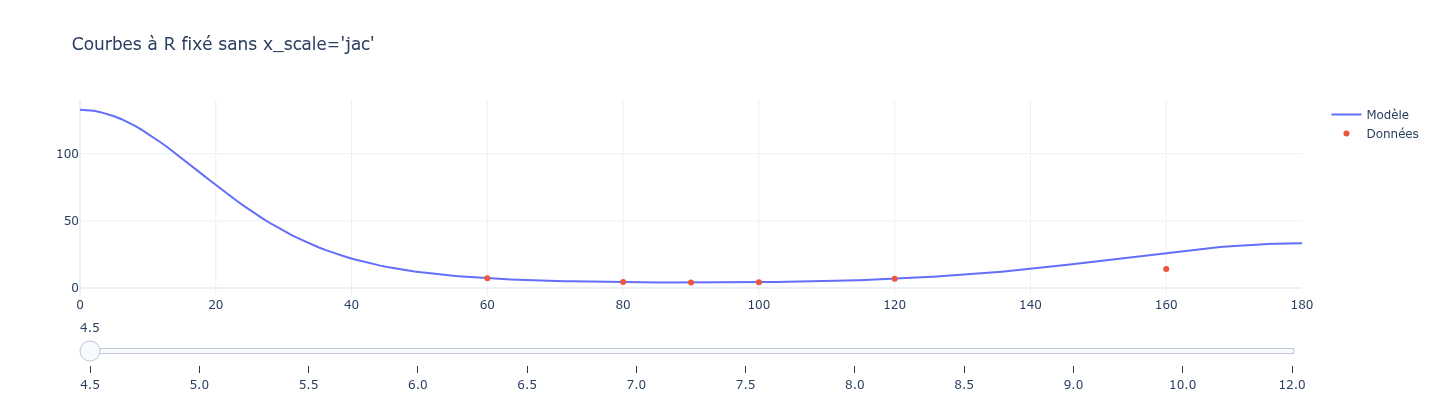

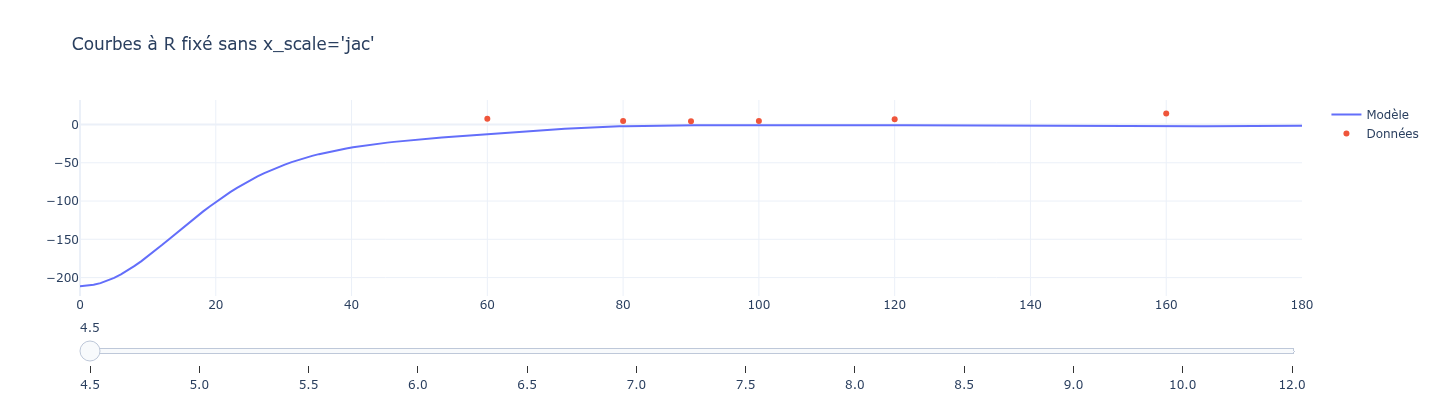

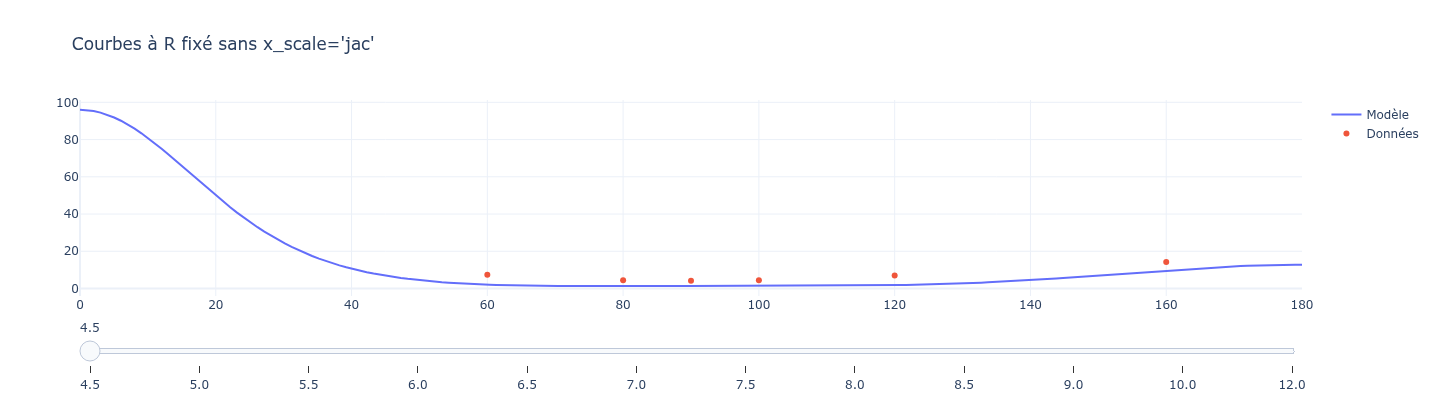

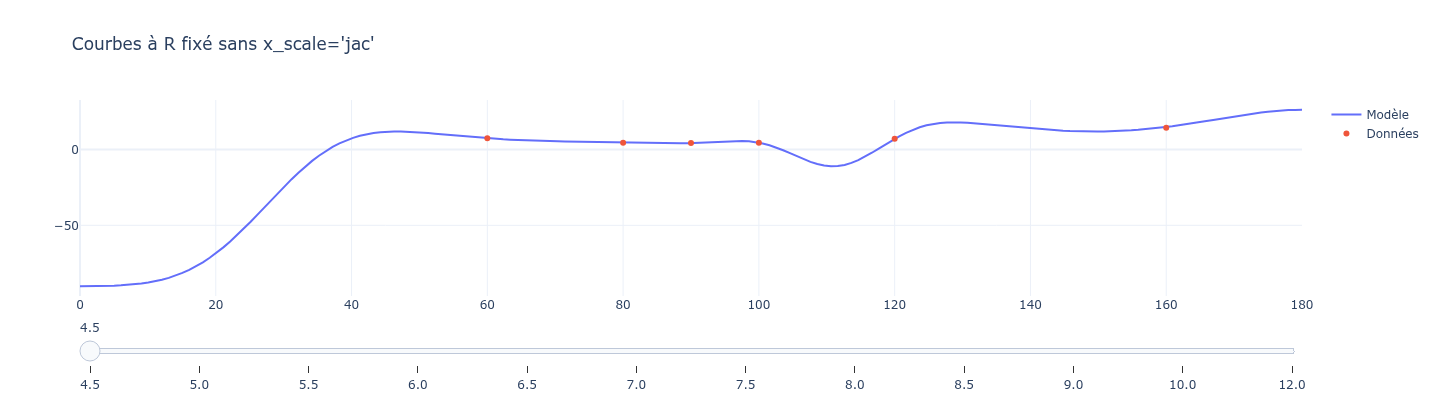

In [40]:
resultRD1 = least_squares(residus1, p0, x_scale = "jac")
p1 = resultRD1.x
resultRD2 = least_squares(residus2, p1, x_scale = "jac")
p2 = resultRD2.x
resultRD3 = least_squares(residus3, p2, x_scale = "jac")
p3 = resultRD3.x

plot_interactif(V_opt, p0, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p1, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p2, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p3, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")

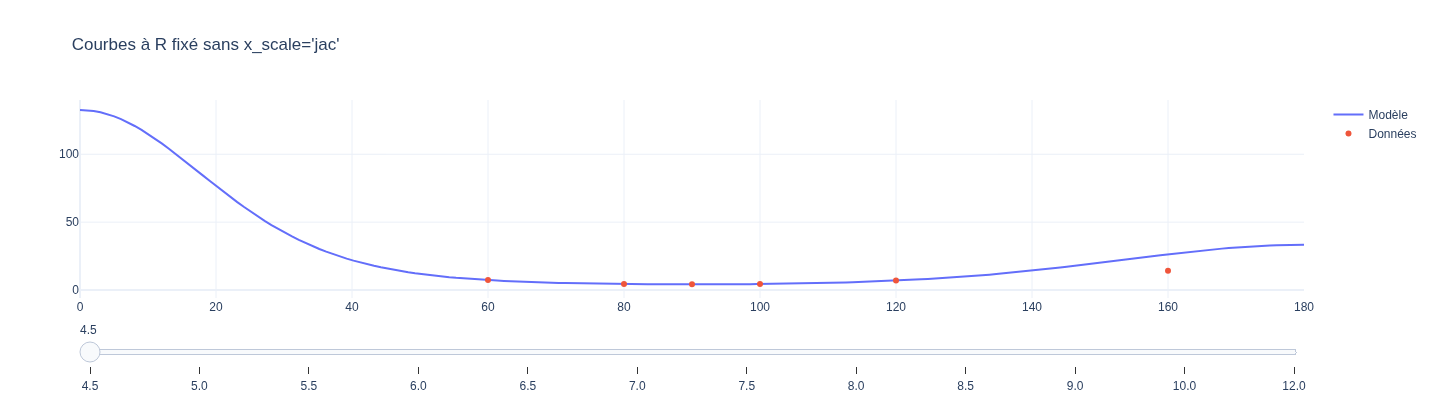

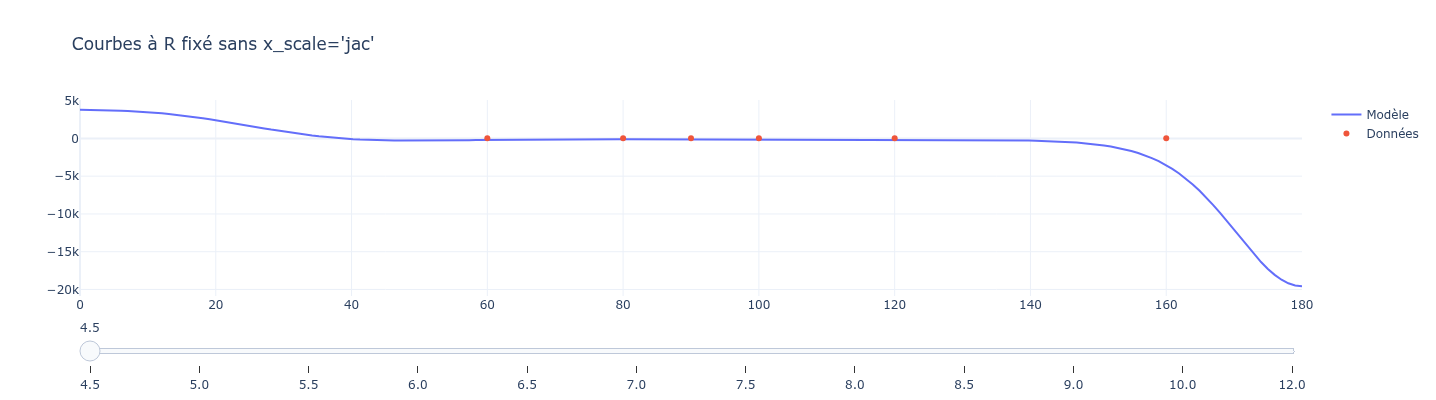

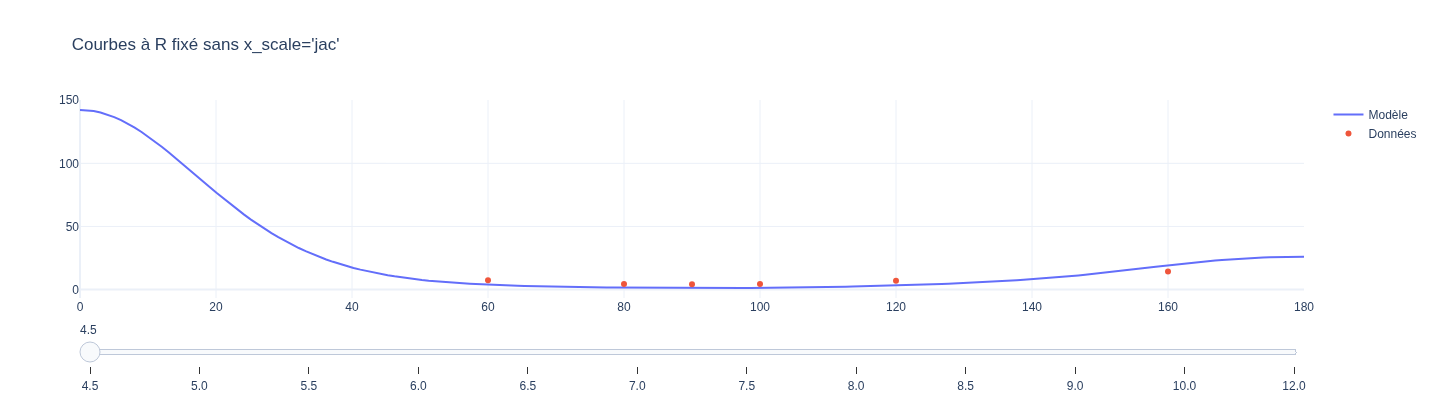

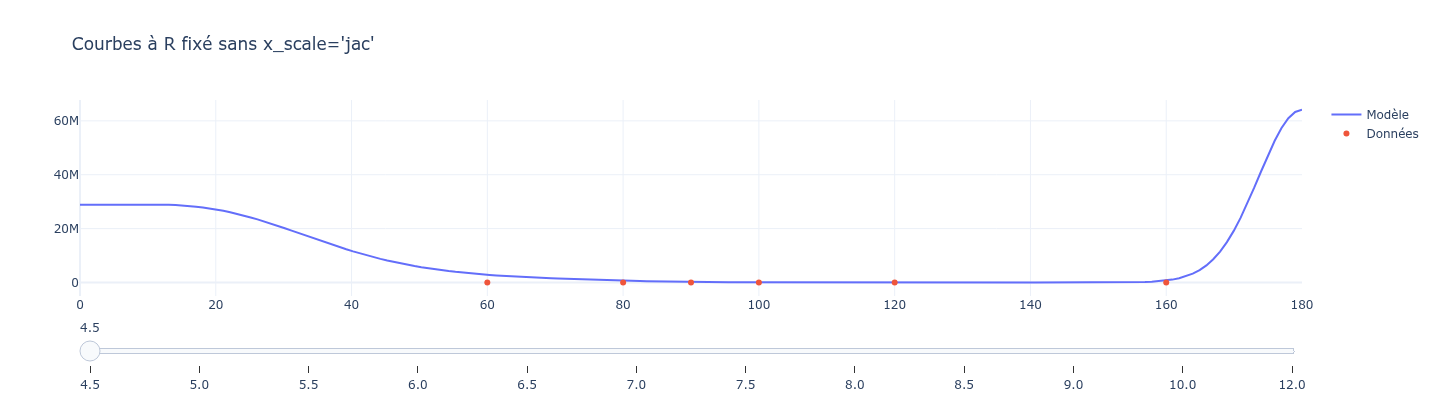

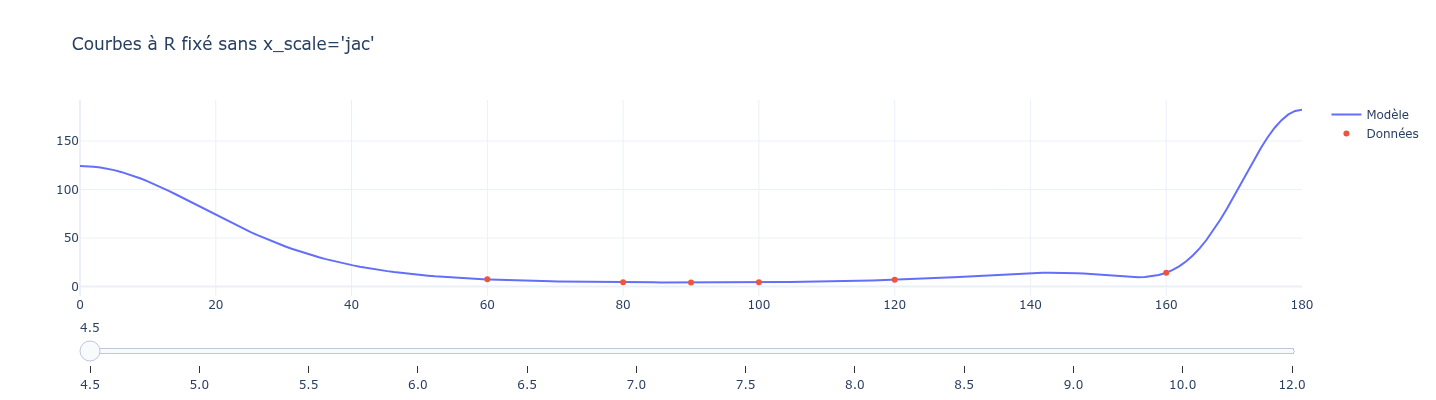

In [41]:
resultRD1 = least_squares(residus1, p0)
p1 = resultRD1.x
resultRD2 = least_squares(residus2, p1)
p2 = resultRD2.x
resultRD2b = least_squares(residus1, p2)
p2b = resultRD2b.x
resultRD3 = least_squares(residus3, p2b)
p3 = resultRD3.x

plot_interactif(V_opt, p0, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p1, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p2, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p2b, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p3, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")